------

# AiED: Artificial intelligence for the detection of intracranial interictal epileptiform discharges
### Dartmouth ECoG Lab 

------

In [1]:
# libraries
from __future__ import print_function, division
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import os
import h5py
import re
import shutil
import copy
import time
import random
import warnings 
import operator
from datetime import datetime
from tqdm import tqdm, tqdm_notebook
from matplotlib.pyplot import specgram
import torch
import torchvision
from torchvision import datasets, models, transforms
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
# from torchtext import data
from sklearn.metrics import precision_score, f1_score, recall_score, accuracy_score, confusion_matrix
from sklearn.metrics.cluster import contingency_matrix
import joblib
import csv
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from scipy.io import loadmat

In [2]:
# mat_file = "/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/LFP_clean_all.mat"
# data = loadmat(mat_file, squeeze_me=True)
# LFP_clean_all_raw = data["LFP_clean_all"]
# LFP_lengths = np.array(data["LFP_lengths"]).reshape(-1)
# all_LFP_clean = [np.array(x).reshape(-1) for x in LFP_clean_all_raw]


# print("Number of LFP:", len(all_LFP_clean))
# print("First LFP shape:", all_LFP_clean[1].shape)
# print("First LFP length:", len(all_LFP_clean[1]))

In [3]:
# count = 0
# for i in range(len(all_LFP_clean)):
#     lfp = np.asarray(all_LFP_clean[i]).reshape(-1)
#     data = pd.DataFrame(lfp.reshape(1, -1))

#     # print("LFP index:", i)
#     # print("data type:", type(data))
#     # print("data shape:", data.shape)
#     spikes = autoDetect(data, 512)
#     count += len(spikes)

#     print("SPIKES DETECTED (TEMP MATCH) = ", len(spikes))
#     print("")
#     print(spikes[:100])
# print(count)

In [4]:
import h5py
import numpy as np
import os, glob
from scipy.io import savemat

def deref_matlab_string_or_ref(f, item):
    # Case 1: HDF5 object reference
    if isinstance(item, h5py.Reference):
        return f[item]

    # Case 2: Dataset containing ASCII codes for string
    if isinstance(item, h5py.Dataset):
        data = item[()]  # get numpy array
        if np.issubdtype(data.dtype, np.integer):  # likely ASCII codes
            return ''.join(chr(c) for c in data.flatten())
        else:
            return data

    # Case 3: Numpy scalar or array
    if isinstance(item, np.ndarray) or np.isscalar(item):
        data = np.array(item)
        # If it's object reference inside an array
        if data.dtype == object and len(data) > 0 and isinstance(data[0], h5py.Reference):
            return f[data[0]]
        # If it's ASCII code array
        if np.issubdtype(data.dtype, np.integer):
            return ''.join(chr(c) for c in data.flatten())

    # Case 4: Something else (like already a string)
    if isinstance(item, (str, bytes)):
        return item.decode() if isinstance(item, bytes) else item

    # If none of the above
    return item


In [5]:
def load_rdata_field(f, field):
    """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
    path = f['q']['Rdata'][field]
    data = np.array(path)

    results = []
    if data.dtype == object:  # multiple blocks
        for ref in data.flatten():
            if isinstance(ref, h5py.Reference):
                results.append(np.array(f[ref]))
    else:  # single dataset
        results.append(data)

    return results

In [6]:
import pandas as pd  
from sklearn import svm
from scipy.io import loadmat
from sklearn.svm import SVC
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import precision_recall_curve
from numpy import savetxt

import umap.umap_ as umap
import seaborn as sns

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import os, glob
import collections
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.preprocessing import normalize
import h5py

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))


all_label = dict()
all_index= dict()
all_index_reverse= dict()
all_label_reverse= dict()


pt_ch_mapping ={
            # "EC130_513": [3],
            "EC130_200": [1,13],
            # "EC131_513": [273, 274, 275, 276, 282, 283, 284],
            # "EC131_513": [273, 275, 282, 284],
            "EC133_200": [282, 291, 292, 293],
            # "EC135_200": [303, 304],
            "EC135_200": [303],
            # "EC137_200": [258, 260, 271, 272],
            "EC137_200": [257, 258, 259, 269],
            # "EC143_513": [327, 329, 336, 338, 339],
            # "EC143_200": [329, 336, 338, 339],
            "EC143_200": [339],
            # "EC157_513": [323, 331, 332],
            # "EC157_200": [321, 323, 331, 332],
            "EC157_200": [321, 332, 333, 334],
            # "EC162_200": [85, 86, 99, 100],
            "EC162_200": [85, 86],
            "EC175_200": [301, 302],
            "EC183_200": [290],
            "EC186_200": [299, 300, 301],
            # "EC187_200": [309, 310, 311],
            "EC187_200": [309, 310],
            # "EC191_513": [2, 3, 4, 11, 12, 13, 65],
            # "EC191_200": [2, 3, 11, 12],
            "EC191_200": [2, 3, 4],
            "EC196_200": [300, 301, 303],
            # "EC219_513": [399, 400, 401, 402, 403],
            # "EC219_200": [399, 400, 401, 403],
            "EC219_200": [399, 400, 402, 403],
            "EC220_200": [53, 54, 76, 77],
            "EC221_200": [376, 377],
            # "EC222_513": [267,268,269,270,277],
            "EC222_200": [267, 268, 269, 270],
            }
pathname = '/scratch/dazhang/MATLAB/'
patient_block_map = collections.defaultdict(list)
for patient, channal_list in pt_ch_mapping.items():
    path = pathname + patient+'/'
    pt = patient[:-4]
    for cur_channel in channal_list:
        cur_channel = str(cur_channel)
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+pt+"/AN/"+pt+"_AN_ch"+cur_channel+"_wSPKS.mat"
        block_names = []
        with h5py.File(file_path, "r") as f:
            blocks_refs = f['q']['blocks'][:]
            for i in range(blocks_refs.shape[1]):
                ref = blocks_refs[0,i]
                dataset = f[ref][:]          # dereference the object
                text = ''.join(chr(c) for c in dataset.flatten())  # convert char codes to string
                block_names.append(text)
            print("Raw data:", pt,  block_names)
            patient_block_map[pt] = block_names

        break
print("patient_block_map: ", patient_block_map)

all_res = []
start_end1 = []

empty_blocks = {"EC133_ch282":{'B67'},
 "EC137_ch259":{'B176'},
 "EC183_ch290":{'B132','B139','B142'},
# The followings are bad channels
 "EC220_ch55":{'B24','B27'},
 "EC220_ch75":{'B24','B27'},
 "EC221_ch375":{'B36','B47'},
 "EC221_ch374":{'B36','B47'},
 "EC196_ch302":{'B21'},
 "EC183_ch289":{'B132','B139','B142','B164'},
 "EC175_ch303":{'B11'},
 "EC157_ch322":{'B46'},
 "EC143_ch330":{'B35'},
 "EC137_ch260":{'B158','B185'},
 "EC137_ch259":{'B176'},
 "EC133_ch294":{'B60','B67'},
 "EC133_ch281":{'B60','B67'},
 "EC130_ch2":{'B8'},
 }



Raw data: EC130 ['B1', 'B6', 'B8']
Raw data: EC133 ['B60', 'B67']
Raw data: EC135 ['B5']
Raw data: EC137 ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185']
Raw data: EC143 ['B18', 'B34', 'B35']
Raw data: EC157 ['B12', 'B28', 'B31', 'B46']
Raw data: EC162 ['B1', 'B4', 'B13', 'B16']
Raw data: EC175 ['B11']
Raw data: EC183 ['B132', 'B139', 'B142', 'B164']
Raw data: EC186 ['B52', 'B56', 'B58']
Raw data: EC187 ['B27', 'B36', 'B39']
Raw data: EC191 ['B13']
Raw data: EC196 ['B21']
Raw data: EC219 ['B45', 'B48']
Raw data: EC220 ['B24', 'B27']
Raw data: EC221 ['B36', 'B47']
Raw data: EC222 ['B28', 'B31', 'B37', 'B40']
patient_block_map:  defaultdict(<class 'list'>, {'EC130': ['B1', 'B6', 'B8'], 'EC133': ['B60', 'B67'], 'EC135': ['B5'], 'EC137': ['B89', 'B99', 'B113', 'B124', 'B139', 'B158', 'B176', 'B185'], 'EC143': ['B18', 'B34', 'B35'], 'EC157': ['B12', 'B28', 'B31', 'B46'], 'EC162': ['B1', 'B4', 'B13', 'B16'], 'EC175': ['B11'], 'EC183': ['B132', 'B139', 'B142', 'B164'], 'EC186': 

In [7]:
file_list = []
all_specs = np.empty((0, 60))
for pt, blocks in patient_block_map.items():
    # if pt == "EC130" or pt == "EC183":
    #     continue
    channel_list = pt_ch_mapping[pt+'_200']
    path = pathname + pt+'_200'+'/'
    
    ls_specs = np.empty((0, 60))
    all_file_list = sorted(glob.glob(os.path.join(path, '*.mat')))
    

    for each_channel in channel_list:
        cur_channel_list = []
        for filename in all_file_list:
            # print(pt, each_channel, filename)
            
            if  ("ls_ripple" not in filename) or  ("binsize_1_" in filename):
                continue
            with open(filename, 'r') as f: 
                
                if "Channel_"+str(each_channel)+"_" in filename and ("-empty" not in filename):
                    # print(filename)
                    specs = loadmat(filename)['ls_ripple']
                    # print(filename, specs.shape)
                    file_list.append(filename)
                    # print(specs.shape)
                    cur_channel_list.append(specs.shape[0])
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)
    all_specs = np.concatenate([all_specs, ls_specs], axis=0)

In [8]:
name_all_list = []
start_all_list = []
patient_num = {
    "EC130_200": 1465,
    "EC133_200": 1220,
    "EC135_200": 344,
    "EC137_200": 7222,
    "EC143_200": 881,
    "EC157_200": 4747,
    "EC162_200": 2398,
    "EC175_200": 518,
    "EC183_200": 220,
    "EC186_200": 1710,
    "EC187_200": 1315,
    "EC191_200": 642,
    "EC196_200": 594,
    "EC219_200": 2015,
    "EC220_200": 2572,
    "EC221_200": 859,
    "EC222_200": 3125}
patient_start = {
    "EC130_200": 0,
    "EC133_200": 1465,
    "EC135_200": 2685,
    "EC137_200": 3029,
    "EC143_200": 10251,
    "EC157_200": 11132,
    "EC162_200": 15879,
    "EC175_200": 18277,
    "EC183_200": 18795,
    "EC186_200": 19015,
    "EC187_200": 20725,
    "EC191_200": 22040,
    "EC196_200": 22682,
    "EC219_200": 23276,
    "EC220_200": 25291,
    "EC221_200": 27863,
    "EC222_200": 28722,
    "end": 31847
}

for name, value in patient_num.items():
    # if name !="EC130_200" and name !="EC183_200":
    name_all_list.extend([name]*value)
    start_all_list.extend([patient_start[name]]*value)

In [9]:
### 4. GENERATE INPUT IMAGES FOR CNN:
IEDdir = '/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/'
non_IEDdir = '/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/NON_IEDS/'
def spectimgs(eegdata, spikedf):    
    """
    SPECTS: GENERATE SPECTS FOR CNN
        INPUT: 1) eegdata, 2) spikedf (df from automated template-matching spike detector)
        OUTPUT: spects within ./SPECTS/IEDS
    """
    for i in tqdm(range(0,len(spikedf))): 
        samp_freq = int(float(spikedf.fs.values[0]))
        #######################################
        pad = 1 # d:1 number of seconds for window 
        dpi_setting = 300 # d:300
        Nfft = 128*(samp_freq/500) # d: 128 
        h = 3
        w = 3
        #######################################
        # try:
        IS_ied = spikedf.ied_or_not.values[i]
        
        subject = spikedf.subject.values[0]
        chan_name = int(spikedf.channel.values[i]) # zero idxed -1
        spikestart = spikedf.spikeTime.values[i][0] # start spike
        ### select eeg data row 
        ecogclip = eegdata.iloc[chan_name]
        ### filter out line noise
        b_notch, a_notch = signal.iirnotch(60.0, 30.0, samp_freq)
        ecogclip = pd.Series(signal.filtfilt(b_notch, a_notch, ecogclip)) 
    
        ### trim eeg clip based on cushion            
        ### mean imputation if missing indices
        end = int(float((spikestart+int(float(pad*samp_freq)))))
        start = int(float((spikestart-int(float(pad*samp_freq)))))
        if end > max(ecogclip.index):
            temp = list(ecogclip[list(range(spikestart-int(float(pad*samp_freq)), max(ecogclip.index)))])
            cushend = [np.mean(ecogclip)]*(end - max(ecogclip.index))
            temp = np.array(temp + cushend)
        elif start < min(ecogclip.index):
            temp = list(ecogclip[list(range(min(ecogclip.index), spikestart+pad*samp_freq))])
            cushstart = [np.mean(ecogclip)]*(min(ecogclip.index)-start)
            temp = np.array(cushstart, temp)
        else:
            temp = np.array(ecogclip[list(range(spikestart-int(float(pad*samp_freq)), 
                                        spikestart+int(float(pad*samp_freq))))]) 
        
        ### PLOT AND EXPORT:
        plt.figure(figsize=(h,w))
        specgram(temp, NFFT = int(Nfft), Fs = samp_freq, noverlap=int(Nfft/2), detrend = "linear", cmap = "YlOrRd") 
        plt.axis("off")
        plt.xlim(0, pad*2)
        plt.ylim(0,100)
        # plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+".png", dpi = dpi_setting)
        # plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(i) + ".png",dpi=dpi_setting)
        cur_count = int(subject.rsplit("_count", 1)[-1])
        global_count = cur_count + i
        if IS_ied==1:
            plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png",dpi=dpi_setting)
        else:
            plt.savefig(non_IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png",dpi=dpi_setting)
        plt.close()


# spectimgs(data, spikes)


In [10]:
file_list = []
hit_count = 0
total_count = 0
all_specs = np.empty((0, 60))
all_LFP_clean = []
all_lengths = []
match_hit = [-1]*31847

for pt, blocks in patient_block_map.items():

    # if pt == "EC130" or pt == "EC183":
    #     continue
    if pt == "EC130" or pt == "EC183":
        continue
    
    channel_list = pt_ch_mapping[pt+'_200']
    path = pathname + pt+'_200'+'/'
    
    ls_specs = np.empty((0, 60))

    for each_channel in channel_list:
        file_path = "/data/an/transformed/RR_h_referential_wSPKS/"+ pt+"/AN/"+pt+"_AN_ch"+str(each_channel)+"_wSPKS.mat"
        
        with h5py.File(file_path, "r") as f:
            ripple_blocks = load_rdata_field(f, 'ripples')
            spike_blocks = load_rdata_field(f, 'Rspikes_THISchannel')
            print(f"{pt} {file_path} {len(blocks)}")  # Print file info once
            
            for ripples, spikes, each_block_name in zip(ripple_blocks, spike_blocks, blocks):
                if pt+'_ch'+str(each_channel) in empty_blocks and each_block_name in empty_blocks[pt+'_ch'+str(each_channel)]: 
                    continue
                else:
                    created_file = 'ls_ripple_'+pt+'_Channel_'+str(each_channel)+'_binsize_10_Block_'+str(blocks.index(each_block_name)+1)
                    # print("created_file ", created_file, blocks)
                    # ls_ripple_EC130_Channel_1_binsize_10_Block_1.mat
                if "Channel_"+str(each_channel)+"_" in created_file and ("-empty" not in created_file):
                    specs = loadmat(path+created_file)['ls_ripple']
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)
                raw_file = "/data/an/preprocessed/"+pt+"/"+pt+"_"+each_block_name+"/MAT files/"+pt+"_"+each_block_name+"_notched.mat"
                a = loadmat(raw_file)
                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                # Ripples: (1, 2) Spikes: (2,)
                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    continue
                print("Ripples:", ripples.T.shape, "Spikes:", spikes.T.shape)
                train_LFPs=[]

                aa = np.hstack([a['d'][:, each_channel]])
                train_LFPs.append(aa[:, np.newaxis])
                bb =  np.vstack([ripples.T])
                averages_per_list = [int(np.mean(sublist)) for sublist in bb]
                # print("Averages per sublist:", averages_per_list)

                
                output=[]
                LFP_clean = np.nan_to_num(train_LFPs[0], nan=0.0, posinf=1e5, neginf=-1e5)
                # Option 2: Clip to float16 valid range if needed
                LFP_clean = np.clip(LFP_clean, -65000, 65000)
                # saved_file_aied = "/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/LFP_clean.csv"
                # np.savetxt(saved_file_aied, LFP_clean.reshape(1, -1), delimiter=",", fmt="%.10g")
                LFP_clean_1d = LFP_clean.reshape(-1)
                LFP_df = pd.DataFrame([LFP_clean_1d])

                spike_times = ripples.T
                spike_times_list = np.asarray(spike_times).astype(int).tolist()
                spikes_or_not = spikes.T.tolist()
                spikes_or_not = [i[0] for i in spikes_or_not]
                assert len(spikes_or_not) == len(spike_times_list)

                # subject = f"{pt}_{each_block_name}_ch{each_channel}_count{total_count}"
                # for i in range(0,len(spike_times_list)):
                #     global_count = total_count + i
                #     each_candidiate = IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png"
                #     # each_candidiate = f"{pt}_{each_block_name}_ch{each_channel}_count{global_count}"
                #     # plt.savefig(IEDdir+subject+"_"+str(spikestart)+"_"+str(chan_name)+"_"+str(global_count) + ".png",dpi=dpi_setting)
                #     all_candi_with_global.append(each_candidiate)

                # print(len(spike_times_list), spike_times_list)

                SPIKES = pd.DataFrame({
                    "channel": [0] * len(spike_times_list),
                    "spikeTime": spike_times_list,
                    "ied_or_not": spikes_or_not,
                    "fs": [512] * len(spike_times_list),
                    # "subject": ["tester1"] * len(spike_times_list)
                    "subject": [f"{pt}_{each_block_name}_ch{each_channel}_count{total_count}"] * len(spike_times_list)
                })

                # total_count += ripples.T.shape[0]
                total_count += len(spikes_or_not)
                spectimgs(LFP_df, SPIKES)

    all_specs = np.concatenate([all_specs, ls_specs], axis=0)                       
                                 
                
# print(hit_count)
print(total_count)


EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch282_wSPKS.mat 2
Ripples: (178, 2) Spikes: (178, 1)


100%|██████████| 178/178 [00:09<00:00, 17.82it/s]


EC133 /data/an/transformed/RR_h_referential_wSPKS/EC133/AN/EC133_AN_ch291_wSPKS.mat 2
Ripples: (170, 2) Spikes: (170, 1)


100%|██████████| 170/170 [00:08<00:00, 19.85it/s]


Ripples: (151, 2) Spikes: (151, 1)


...

Ripples: (160, 2) Spikes: (160, 1)


100%|██████████| 160/160 [00:08<00:00, 19.23it/s]


Ripples: (209, 2) Spikes: (209, 1)


100%|██████████| 209/209 [00:10<00:00, 19.05it/s]

30162


In [11]:
### 5. ResNet-18 CNN DETECTOR:

### A: LOAD ALL DATA --- extract clip_id from path
eegdir = os.getcwd() ################################################################################ CHANGE: dir here
model_dir = eegdir+"/" # dir with trained model ################################################## CHANGE: dir here
proj_dir = eegdir+"/" # dir with main project script ############################################# CHANGE: dir here
imgs = 'SPECTS_compare' # dir with IED / NONIED image dirs (name of subdir)

data_transforms = {
    imgs: transforms.Compose([
        transforms.Resize(224),
        transforms.Pad(1, fill=0, padding_mode='constant'),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])}


class ImageFolderWithPaths(datasets.ImageFolder):
    """Custom dataset that includes image path and global count."""
    def __getitem__(self, index):
        # original_tuple = (image, label)
        original_tuple = super(ImageFolderWithPaths, self).__getitem__(index)
        path = self.imgs[index][0]
        filename = os.path.splitext(os.path.basename(path))[0]
        global_count = int(filename.rsplit('_', 1)[-1])
        tuple_with_path = original_tuple + (path, global_count)
        return tuple_with_path
    
image_datasets = {x: ImageFolderWithPaths(os.path.join(proj_dir, x), data_transforms[x]) for x in [imgs]}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=1, shuffle=False, num_workers=0) for x in [imgs]} 
class_names = image_datasets[imgs].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# extract image paths
# path_names = []
# for images,labels,paths in dataloaders[imgs]:
#     path_names.append(paths)

path_names = []
global_count_list = []

for images, labels, paths, global_counts in dataloaders[imgs]:
    path_names.extend(paths)
    global_count_list.extend(global_counts.tolist())


In [12]:
# df = pd.DataFrame(path_names)
df = pd.DataFrame({
    "clip_ids": path_names,
    "global_count": global_count_list
})
df

,clip_ids,global_count
0,/home/dazhang/Documents/kleen_git/time-frequen...,117
1,/home/dazhang/Documents/kleen_git/time-frequen...,126
2,/home/dazhang/Documents/kleen_git/time-frequen...,130
3,/home/dazhang/Documents/kleen_git/time-frequen...,131
4,/home/dazhang/Documents/kleen_git/time-frequen...,24
...,...,...
30157,/home/dazhang/Documents/kleen_git/time-frequen...,30073
30158,/home/dazhang/Documents/kleen_git/time-frequen...,30074
30159,/home/dazhang/Documents/kleen_git/time-frequen...,30075
30160,/home/dazhang/Documents/kleen_git/time-frequen...,30076


In [13]:
y_pred = []
y_pred_prob = []
y_true = []

pred_by_global_count = [-1] * 30162
prob_by_global_count = [np.nan] * 30162
true_by_global_count = [-1] * 30162

import torch.nn.functional as F
try:
    # model = torch.load(model_dir+'model_aied.pt')
    model = torch.load('../model_aied.pt')
    # model.eval() # model architecture
except ImportError:
    print('TRAINED MODEL NOT FOUND: Check that trained model is in eegdir and name matches: model_aied.pt')
    

model = model.to(device)
model.eval()

count = 0

with torch.no_grad():
    for inputs, labels, paths, global_counts in dataloaders[imgs]:

        inputs = inputs.to(device)
        labels = labels.to(device)

        # 只运行一次模型
        outputs = model(inputs)

        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, 1)
        pred_prob = probs[:, 1]

        # batch_size=1，所以可以使用 item()
        global_count = int(global_counts.item())
        pred_value = int(predicted.item())
        prob_value = float(pred_prob.item())
        true_value = int(labels.item())

        # 根据 global_count 放入对应位置
        pred_by_global_count[global_count] = pred_value
        prob_by_global_count[global_count] = prob_value
        true_by_global_count[global_count] = true_value

        # 保留原来的 list
        y_pred.append(pred_value)
        y_pred_prob.append(prob_value)
        y_true.append(true_value)

        count += 1

        print(
            "global_count:", global_count,
            "label:", true_value,
            "prediction:", pred_value,
            "path:", paths[0]
        )
        print(count)

global_count: 117 label: 0 prediction: 0 path: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/EC133_B60_ch282_count0_102466_0_117.png
1
global_count: 126 label: 0 prediction: 0 path: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/EC133_B60_ch282_count0_108292_0_126.png
2
global_count: 130 label: 0 prediction: 0 path: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/EC133_B60_ch282_count0_115433_0_130.png
3
global_count: 131 label: 0 prediction: 1 path: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aied/notebooks/SPECTS_compare/IEDS/EC133_B60_ch282_count0_115684_0_131.png
4
global_count: 24 label: 0 prediction: 0 path: /home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/aie

In [14]:
import pickle

data = prob_by_global_count  # list of 30162 floats
with open("/home/dazhang/Documents/kleen_git/time-frequency-powerspectrum/llama2.c/clean_spike_ripple/AiED_30162.pkl", "wb") as f:
    pickle.dump(data, f)

In [15]:
plasma = plt.cm.get_cmap('plasma')
values = np.linspace(0, 1, 100)
colors = plasma(values)
all_ripples = all_specs
all_vectors = np.asarray(all_ripples)
embedding = umap.UMAP(n_components=2, min_dist=0.2, metric='euclidean',n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

kmeans = KMeans(n_clusters = 5,random_state = 920, n_init=10)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)


UMAP(min_dist=0.2, n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Thu Sep 10 06:46:34 2026 Construct fuzzy simplicial set
Thu Sep 10 06:46:34 2026 Finding Nearest Neighbors
Thu Sep 10 06:46:34 2026 Building RP forest with 14 trees


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Thu Sep 10 06:46:37 2026 NN descent for 15 iterations


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x76900d835790>>
Traceback (most recent call last):
  File "/home/dazhang/anaconda3/envs/klab/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Thu Sep 10 06:46:50 2026 Finished Nearest Neighbor Search
Thu Sep 10 06:46:52 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Thu Sep 10 06:46:58 2026 Finished embedding


(30162, 2)
{0: 'blue', 1: 'pink', 2: 'green', 3: 'cyan', 4: 'red'}
30162
30162
[0.02366097 0.03587969 0.03960144 ... 0.27970043 0.11686648 0.84166193] 4067 0.6509339709654918
[0.99012178 0.98998743 0.97339362 ... 0.98259246 0.94104046 0.93913412] 6165 0.07238205942141751
[0.9895699  0.95458025 0.36284235 ... 0.99674976 0.78566998 0.98824805] 5961 0.04431459329434262
[0.98598588 0.99543214 0.99517268 ... 0.99686396 0.9683584  0.98289943] 8614 0.034849186953773925
[0.98444796 0.97698271 0.99343187 ... 0.9647038  0.21522148 0.9898392 ] 5355 0.1211720519763505


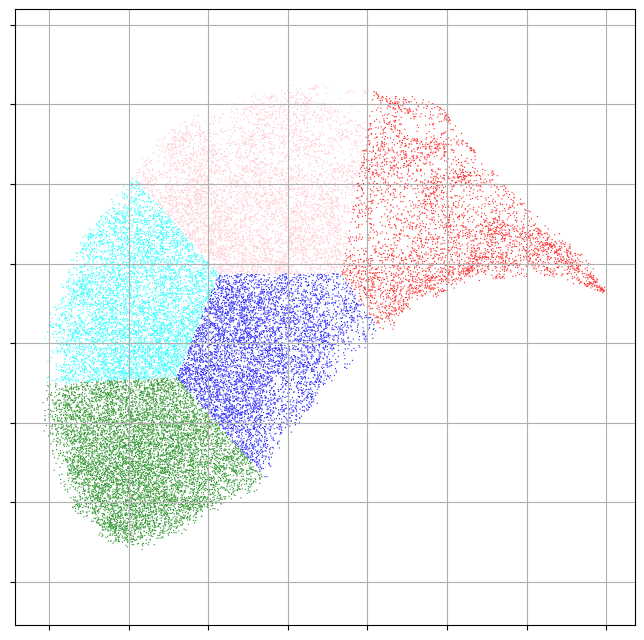

In [16]:
len(prob_by_global_count)

D_id_color = {}
D_id_color[0] = 'blue'
D_id_color[1] = 'pink'
D_id_color[2] = 'green'
D_id_color[3] = 'cyan'
D_id_color[4] = 'red'

print(embedding.shape)
print(D_id_color)
print(len(prob_by_global_count))
print(len(kmeans_label.labels_))
prob_by_global_count = np.asarray(prob_by_global_count)

idx = np.where(kmeans_label.labels_ == 4)[0]
cluster_4_data = prob_by_global_count[idx]
print(cluster_4_data, len(cluster_4_data), 1-np.mean(cluster_4_data))

idx = np.where(kmeans_label.labels_ == 0)[0]
cluster_0_data = prob_by_global_count[idx]
print(cluster_0_data, len(cluster_0_data), 1-np.mean(cluster_0_data))


idx = np.where(kmeans_label.labels_ == 3)[0]
cluster_3_data = prob_by_global_count[idx]
print(cluster_3_data, len(cluster_3_data), 1-np.mean(cluster_3_data))


idx = np.where(kmeans_label.labels_ == 2)[0]
cluster_2_data = prob_by_global_count[idx]
print(cluster_2_data, len(cluster_2_data), 1-np.mean(cluster_2_data))


idx = np.where(kmeans_label.labels_ == 1)[0]
cluster_1_data = prob_by_global_count[idx]
print(cluster_1_data, len(cluster_1_data), 1-np.mean(cluster_1_data))





fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=[D_id_color[f] for f in kmeans_label.labels_], s=0.8)
ax.figure.show()
ax.grid(True)
ax.axis('equal')
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.show()
# ax.figure.savefig("kmeans_label_dots_"+str(number_cluster)+"_200.png")
# plt.close()

Cluster 1 : mean=0.0348, SEM=0.0014
Cluster 2 : mean=0.0443, SEM=0.0018
Cluster 3 : mean=0.0724, SEM=0.0024
Cluster 4 : mean=0.1212, SEM=0.0033
Cluster 5 : mean=0.6509, SEM=0.0060


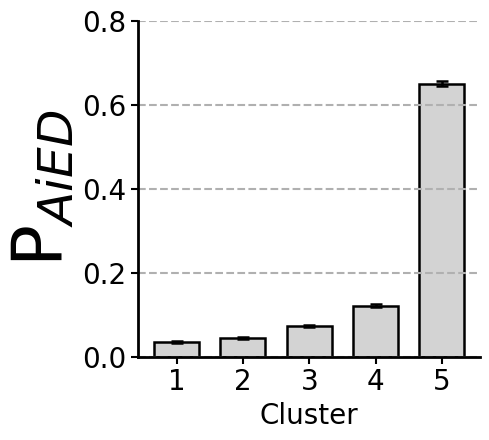

In [17]:
cluster_data = [
    np.asarray(cluster_2_data),
    np.asarray(cluster_3_data),
    np.asarray(cluster_0_data),
    np.asarray(cluster_1_data),
    np.asarray(cluster_4_data)
]

cluster_means = [1 - np.nanmean(data) for data in cluster_data]

cluster_sems = [
    np.nanstd(data, ddof=1) / np.sqrt(np.sum(~np.isnan(data)))
    for data in cluster_data
]

cluster_display_order = [1, 2, 3, 0, 4]
for bar_idx, (cluster_id, mean, sem) in enumerate(
    zip(cluster_display_order, cluster_means, cluster_sems),
    start=1
):
    print(
        f"Cluster {bar_idx} : "
        f"mean={mean:.4f}, "
        f"SEM={sem:.4f}"
    )



labels = ["1", "2", "3", "4", "5"]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 4.5))

bars = ax.bar(
    x,
    cluster_means,
    width=0.68,
    color="lightgray",
    edgecolor="black",
    linewidth=1.8,
    yerr=cluster_sems,
    capsize=4,
    error_kw={
        "ecolor": "black",
        "elinewidth": 1.8,
        "capthick": 1.8
    }
)

# for bar, mean, sem in zip(bars, cluster_means, cluster_sems):
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         mean + sem + 0.012,
#         f"{mean:.3f} ± {sem:.3f}",
#         ha="center",
#         va="bottom",
#         fontsize=13,
#         fontweight="bold"
#     )

# Axis labels
ax.set_xlabel("Cluster", fontsize=20)
ax.set_ylabel("P$_{AiED}$", fontsize=50)

# Tick labels
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=20)
ax.tick_params(axis='y', labelsize=20)

# Y axis
ax.set_ylim(0, 0.8)
ax.grid(
    True,
    axis="y",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)

# Remove grid
# ax.grid(False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make axes thicker
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

# Tick marks
ax.tick_params(
    axis='both',
    width=1.5,
    length=5
)

plt.tight_layout()
plt.show()

In [18]:
y_pred_flat = np.array(pred_by_global_count)
# sum(y_pred_flat)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

all_pt_color = []

for label in y_pred_flat:
    if label == 0:
        all_pt_color.append([1, 0, 0, 1])  # fully transparent
    else:
        all_pt_color.append([0, 0, 0, 0.1])  # red
    
# len(all_vectors)

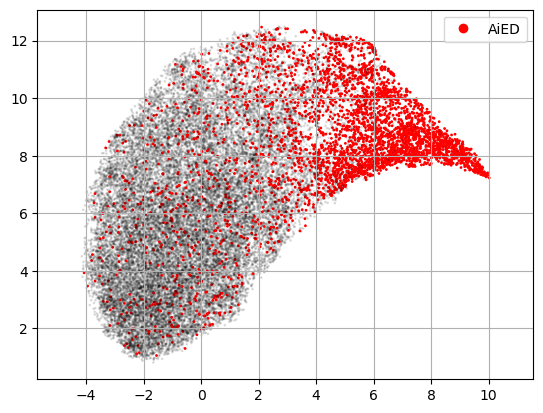

In [19]:

plt.figure()

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=all_pt_color,
    s=1.0
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="none",
        markersize=7,
        label="AiED"
    ),
    # Line2D(
    #     [0], [0],
    #     marker="o",
    #     color="none",
    #     markerfacecolor="green",
    #     markeredgecolor="none",
    #     markersize=7,
    #     label="Non-hit"
    # )
]

plt.legend(handles=legend_handles, loc="best")

plt.grid(True)
plt.axis("equal")
plt.show()

In [20]:
# prob_by_global_count

In [ ]:
min_prob = round(min(prob_by_global_count),2)
max_prob = round(max(prob_by_global_count),2)
prob_space = np.linspace(min_prob, max_prob, num=100)  # 100 points between 0.5 and 1

all_pt_color = []
prob_values = []
# 
mapped_min = float('inf')
mapped_max = -float('inf')

for i, txt in enumerate(prob_by_global_count):
    ripple_prob = prob_by_global_count[i]
    neareast_prob = min(prob_space, key=lambda x: abs(x - ripple_prob))
    mapped_values = (neareast_prob - min_prob) / (max_prob - min_prob)

    mapped_min = min(mapped_min, mapped_values)
    mapped_max = max(mapped_max, mapped_values)
    
    prob_values.append(ripple_prob)
    cc = plasma(mapped_values)
    # print(cc)
    all_pt_color.append(cc[:-1])


# ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=all_pt_color, s=5.0)
# ax.grid(True)
# ax.axis('equal')

length of grid entropy:  {(np.int64(6), np.int64(12)): 161, (np.int64(7), np.int64(12)): 146, (np.int64(6), np.int64(10)): 233, (np.int64(11), np.int64(8)): 6, (np.int64(4), np.int64(3)): 246, (np.int64(3), np.int64(5)): 286, (np.int64(3), np.int64(6)): 237, (np.int64(3), np.int64(15)): 113, (np.int64(5), np.int64(17)): 100, (np.int64(14), np.int64(16)): 73, (np.int64(8), np.int64(19)): 63, (np.int64(2), np.int64(11)): 171, (np.int64(9), np.int64(13)): 138, (np.int64(10), np.int64(16)): 82, (np.int64(7), np.int64(16)): 118, (np.int64(2), np.int64(7)): 244, (np.int64(2), np.int64(5)): 234, (np.int64(2), np.int64(2)): 267, (np.int64(3), np.int64(3)): 312, (np.int64(5), np.int64(5)): 248, (np.int64(1), np.int64(7)): 165, (np.int64(15), np.int64(11)): 28, (np.int64(6), np.int64(8)): 183, (np.int64(5), np.int64(9)): 220, (np.int64(15), np.int64(15)): 55, (np.int64(2), np.int64(1)): 254, (np.int64(1), np.int64(6)): 185, (np.int64(3), np.int64(13)): 153, (np.int64(3), np.int64(0)): 120, (np.i

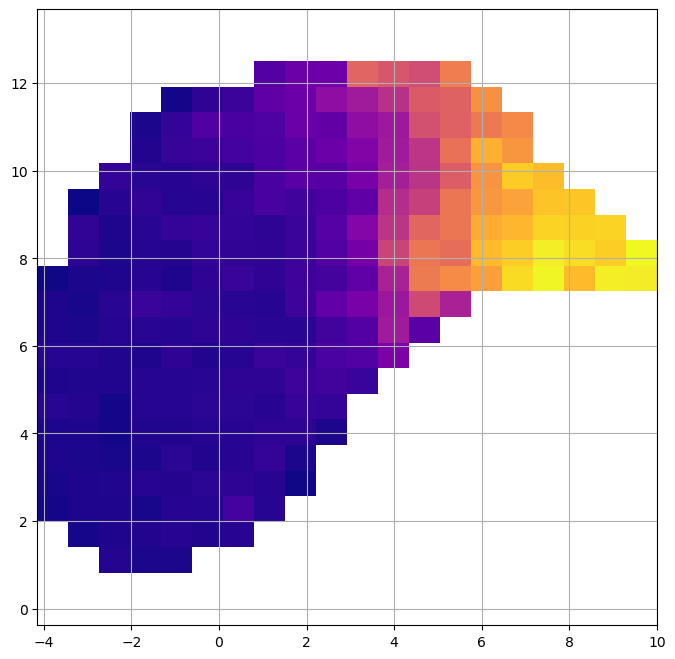

In [22]:
min_vals = np.min(embedding, axis=0)
max_vals = np.max(embedding, axis=0)
# min_vals = [-4.1483297,  0.8951096]
# max_vals = [ 9.943624, 12.604202]

patient_label = {
"EC130_200":1,
"EC133_200" :2,
"EC135_200" :3,
"EC137_200": 4,
"EC143_200" :5,
"EC157_200" :6,
"EC162_200" :7,
"EC175_200" :8,
"EC183_200" :9,
"EC186_200" :10,
"EC187_200" :11,
"EC191_200" :12,
"EC196_200" :13,
"EC219_200" :14,
"EC220_200" :15,
"EC221_200":16,
"EC222_200" :17}


grid_size = (20, 20)  # Number of divisions in x and y dimensions
x_bins = np.linspace(min_vals[0], max_vals[0], grid_size[0] + 1)
y_bins = np.linspace(min_vals[1], max_vals[1], grid_size[1] + 1)
ratio = (max_vals[1] - min_vals[1])/(max_vals[0] - min_vals[0])

grid_entropy = dict()
grid_entropy_count = dict()
grid_entropy_patient_count = dict()
for (x, y), prob, patient in zip(embedding, prob_by_global_count, name_all_list):
    x_idx = np.searchsorted(x_bins, x) - 1
    y_idx = np.searchsorted(y_bins, y) - 1
    if 0 <= x_idx < grid_size[0] and 0 <= y_idx < grid_size[1]:
        if (x_idx, y_idx) not in grid_entropy:
            grid_entropy[x_idx, y_idx] = 0.0
            grid_entropy_count[x_idx, y_idx] = 0
            grid_entropy_patient_count[(x_idx, y_idx)] = set()
        # else:
        grid_entropy[x_idx, y_idx] += prob
        grid_entropy_count[x_idx, y_idx] += 1
        grid_entropy_patient_count[(x_idx, y_idx)].add(patient)


print("length of grid entropy: ", grid_entropy_count)
grid_entropy_value = np.zeros(grid_size)
while_x = grid_size[0]
while_y = grid_size[1]

for i in range(while_x):
    for j in range(while_y):
        if (i, j) not in grid_entropy or (grid_entropy_count[i, j]==0):
            grid_entropy_value[i, j] = 0.0
        elif ((i, j) in grid_entropy) and ((len(grid_entropy_patient_count[(i, j)])<=1)):
            print("!!!!!!!!!!!!!!!", (i, j), len(grid_entropy_patient_count[(i, j)]))
            grid_entropy_value[i, j] = 0.0
        else:
            # print(grid_entropy[x_idx, y_idx], grid_entropy_count[x_idx, y_idx])
            grid_entropy_value[i, j] = 1-grid_entropy[i, j] / grid_entropy_count[i, j]




fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')
cmap = plt.cm.plasma.copy()  # Copy the colormap to modify it
cmap.set_bad(color='white')  # Set masked values (0.0) to white

# Mask NaN values in the data to enforce white background
masked_data = np.ma.masked_where(grid_entropy_value.T == 0.0, grid_entropy_value.T)

print(np.max(masked_data), np.min(masked_data))
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)
ratio = (min_vals[0] - max_vals[0])/(min_vals[1]- max_vals[1])
print(min_vals[0], max_vals[0], min_vals[1], max_vals[1], ratio)

# c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])
# norm = plt.Normalize(mapped_min, mapped_max)
# sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
# sm.set_array([]) 

# cbar = plt.colorbar(sm, cax = cax, orientation='vertical')


c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])
# cbar = plt.colorbar(c2, cax = cax, orientation='vertical')
# cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
# cbar.ax.set_yticklabels([]) 
plt.show()

In [23]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import cKDTree

labels = np.asarray(kmeans_label.labels_)

# ------------------------------------------------------------
# Build boundary grid
# ------------------------------------------------------------
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()

pad_x = 0.02 * (x_max - x_min)
pad_y = 0.02 * (y_max - y_min)

xx, yy = np.meshgrid(
    np.linspace(x_min - pad_x, x_max + pad_x, 500),
    np.linspace(y_min - pad_y, y_max + pad_y, 500)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

# ------------------------------------------------------------
# KNN label field
# ------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(embedding, labels)

Z = knn.predict(grid_points).reshape(xx.shape)

# ------------------------------------------------------------
# Mask far-away empty regions, so lines do not extend too long
# ------------------------------------------------------------
tree = cKDTree(embedding)
dist, _ = tree.query(grid_points, k=1)
dist = dist.reshape(xx.shape)

dist_thresh = 0.15   # 可调：更小=线更短
Z_masked = np.ma.masked_where(dist > dist_thresh, Z)

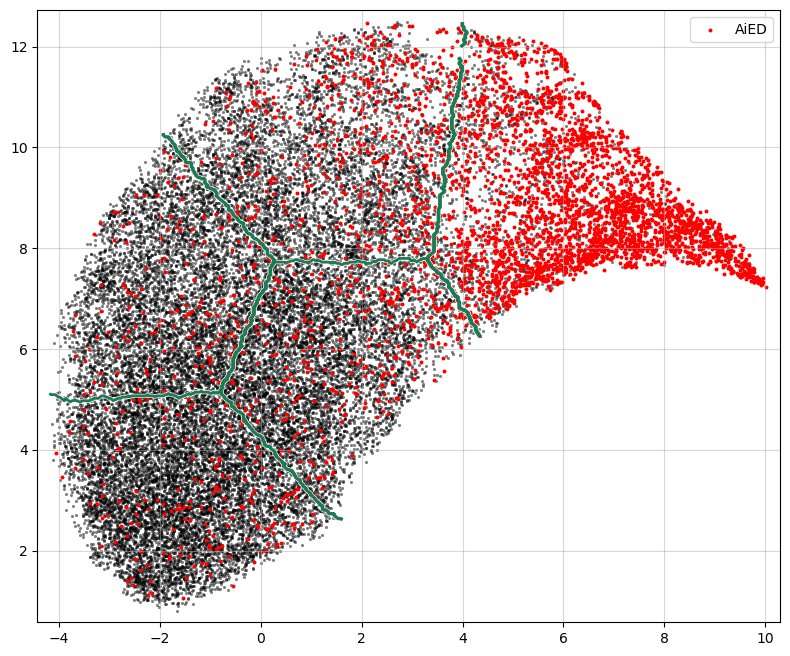

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
mask_aied = (np.asarray(y_pred_flat) == 0)

ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c='black',
    s=5,
    linewidths=0,
    alpha=0.5
)

# 你的 AiED 点
ax.scatter(
    embedding[mask_aied, 0],
    embedding[mask_aied, 1],
    c='red',
    s=8,
    linewidths=0,
    label='AiED'
)

# superimpose boundary
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors='white',
    linewidths=3.0,
    alpha=0.9
)

# dark blue boundary
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors="#1f7952",
    linewidths=2,
    alpha=1.0
)

ax.legend()
ax.grid(True, alpha=0.5)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

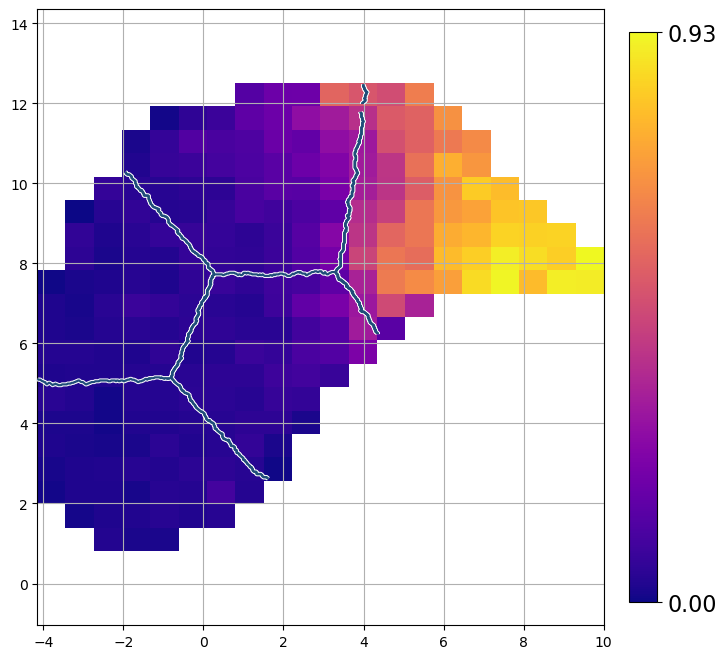

In [25]:
# ============================================================
# Plot heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.grid(True)
ax.axis('equal')
ax.set_facecolor('white')

cmap = plt.cm.plasma.copy()
cmap.set_bad(color='white')

masked_data = np.ma.masked_where(
    grid_entropy_value.T == 0.0,
    grid_entropy_value.T
)

c2 = ax.imshow(
    masked_data,
    origin='lower',
    cmap=cmap,
    extent=[
        min_vals[0],
        max_vals[0],
        min_vals[1],
        max_vals[1]
    ],
)

# c2 = ax.imshow(masked_data, origin='lower', cmap=plasma, extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]])


# ============================================================
# Add K-Means cluster boundaries
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import cKDTree

# IMPORTANT:
# Use the SAME embedding that generated kmeans_label
cluster_embedding = embedding

cluster_labels = np.asarray(
    kmeans_label.labels_
)

assert len(cluster_embedding) == len(cluster_labels)


# Fine grid for smooth boundary
xx, yy = np.meshgrid(
    np.linspace(
        min_vals[0],
        max_vals[0],
        600
    ),
    np.linspace(
        min_vals[1],
        max_vals[1],
        600
    )
)

grid_points = np.c_[
    xx.ravel(),
    yy.ravel()
]


# KNN reconstructs the cluster regions in UMAP space
knn = KNeighborsClassifier(
    n_neighbors=15
)

knn.fit(
    cluster_embedding,
    cluster_labels
)

Z = knn.predict(
    grid_points
).reshape(xx.shape)


# ============================================================
# Remove boundary lines in empty regions
# ============================================================

tree = cKDTree(
    cluster_embedding
)

dist, _ = tree.query(
    grid_points,
    k=1
)

dist = dist.reshape(xx.shape)


# Smaller = shorter lines
dist_thresh = 0.15

Z_masked = np.ma.masked_where(
    dist > dist_thresh,
    Z
)


# ============================================================
# Draw boundaries
# ============================================================

# white halo underneath
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors='white',
    linewidths=3.0,
    alpha=0.95,
    zorder=10
)

# dark-blue main line
ax.contour(
    xx,
    yy,
    Z_masked,
    levels=[0.5, 1.5, 2.5, 3.5],
    colors='#1f4e79',
    linewidths=1.5,
    alpha=1.0,
    zorder=11
)


# ============================================================
# Colorbar
# ============================================================

norm = plt.Normalize(
    mapped_min,
    mapped_max
)

sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=norm
)

sm.set_array([])


vmin = np.nanmin(masked_data)
vmax = np.nanmax(masked_data)

cbar = plt.colorbar(
    c2,
    ax=ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.2f}",
    f"{vmax:.2f}"
])

cbar.ax.tick_params(labelsize=16)

plt.show()

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

vmin = np.nanmin(masked_data)
vmax = np.nanmax(masked_data)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="plasma")

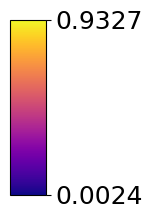

In [30]:
fig = plt.figure(figsize=(1.2, 5))

cax = fig.add_axes([0.45, 0.4, 0.3, 0.35])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.4f}",
    f"{vmax:.4f}"
])

cbar.ax.tick_params(labelsize=18)

plt.show()

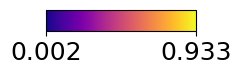

In [31]:
fig = plt.figure(figsize=(5, 1.2))

cax = fig.add_axes([0.4, 0.45, 0.3, 0.18])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)

cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels([
    f"{vmin:.3f}",
    f"{vmax:.3f}"
])

cbar.ax.tick_params(labelsize=18)

plt.show()